# Пример 08. Инвертирование матриц

## Тема

**Раздел книги:** Линейная алгебра.  
**Математическая тема:** обратимые матрицы, проверка обратимости, вычисление $A^{-1}$; связь с нормализующими потоками в генеративных моделях.

## Условие

Для двух матриц разного размера

$$A = \begin{pmatrix}2 & 3 & 4 \\ 3 & 4 & 5 \\ 4 & 5 & 6\end{pmatrix},\quad B = \begin{pmatrix}1 & 0 & 1 & 0 \\ 0 & 1 & 1 & 0 \\ 1 & 1 & 0 & 1 \\ 1 & 1 & 1 & 0\end{pmatrix}$$

требуется проверить, существует ли обратная матрица, и если да — вычислить её.

## Математическая идея

Матрица $A\in\mathbb{R}^{n\times n}$ обратима тогда и только тогда, когда $\det A \ne 0$ (эквивалентно: $A$ имеет полный ранг, или её столбцы линейно независимы). Обратная матрица $A^{-1}$ удовлетворяет условию

$$A A^{-1} = A^{-1} A = I_n.$$

Для проверки достаточно:

1. вычислить $\det A$;
2. если $\det A \ne 0$, найти $A^{-1}$;
3. убедиться, что $A A^{-1} \approx I$.

## Решение

1. Для матрицы $3\times 3$ вычисляется определитель. Если он близок к нулю, матрица необратима (в данном случае строки линейно зависимы — это матрица типа Ганкеля).
2. Для матрицы $4\times 4$ проверяется обратимость и вычисляется $A^{-1}$.
3. Проверяется, что $A A^{-1} = I$.

## Реализация на Python

Используются `np.linalg.det(A)` для определителя, `np.linalg.inv(A)` для обратной матрицы и `np.allclose(A @ A_inv, np.eye(n))` для проверки. Если матрица вырождена, `np.linalg.inv` выбрасывает `LinAlgError`, что обрабатывается явно или фиксируется по значению определителя.


In [1]:
import numpy as np

# Проверка обратимости для пункта b
A = np.array([
    [1, 0, 1, 0],
    [0, 1, 1, 0],
    [1, 1, 0, 1],
    [1, 1, 1, 0]
])

# Вычисление обратной матрицы
A_inv = np.linalg.inv(A)
print("Обратная матрица:\n", A_inv)

# Проверка: A * A_inv должно быть близко к I
print("\nПроверка А * А_inv:\n", A @ A_inv)

Обратная матрица:
 [[ 0. -1.  0.  1.]
 [-1.  0.  0.  1.]
 [ 1.  1. -0. -1.]
 [ 1.  1.  1. -2.]]

Проверка А * А_inv:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## Дополнительный пример

**Идея.** Нормализующий поток — это последовательность обратимых преобразований $x = f(z) = W z + b$, которые превращают простое распределение $z\sim\mathcal{N}(0, I)$ в сложное распределение $x$. Благодаря обратимости можно точно вычислить плотность $p(x)$ через замену переменной:

$$p(x) = p(z)\left|\det\frac{\partial f^{-1}}{\partial x}\right|.$$

Для линейного преобразования $x = Wz + b$ якобиан равен $W^{-1}$, поэтому $|\det J| = |\det W|^{-1}$.

**Что демонстрирует код.** Из стандартного нормального распределения генерируются 1000 точек $z\in\mathbb{R}^2$. Применяется линейное преобразование $x = z W + b$ с матрицей $W = \begin{pmatrix}2 & 1 \\ 1 & 1\end{pmatrix}$, $\det W = 1 \ne 0$. Затем через `np.linalg.inv(W)` выполняется обратное преобразование, и проверяется, что исходные $z$ восстанавливаются с нулевой ошибкой.


### 🔁 Как обратимые матрицы используются в нормализующих потоках для генеративных моделей? Простой нормализующий поток на Python

det(W) =  1.0
Ошибка восстановления: 1.833908459120126e-16


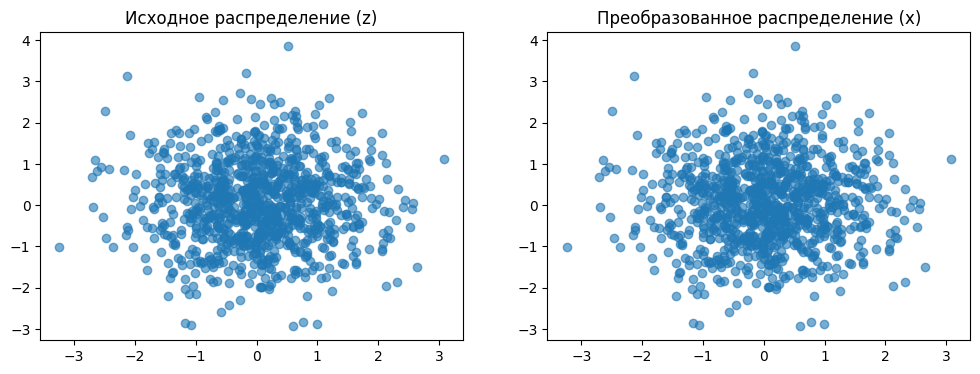

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Создаём простое распределение (z ~ N(0, I))
np.random.seed(42)
z = np.random.randn(1000, 2)

# Применяем обратимое линейное преобразование
W = np.array([[2, 1], [1, 1]])  # Обратимая матрица (det = 1)
b = np.array([1, 2])
x = z @ W + b

# Обратное преобразование
W_inv = np.linalg.inv(W)
z_recovered = (x - b) @ W_inv

# Проверка обратимости
print("det(W) = ", np.linalg.det(W))  # Должно быть != 0
print("Ошибка восстановления:", np.mean(np.abs(z - z_recovered)))

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(z[:, 0], z[:, 1], alpha=0.6)
plt.title("Исходное распределение (z)")

plt.subplot(1, 2, 2)
plt.scatter(z[:, 0], z[:, 1], alpha=0.6)
plt.title("Преобразованное распределение (x)")
plt.show()

## Проверка результата

В первой части корректность обратной матрицы проверяется условием $A A^{-1} = I$. Во второй части проверяется, что $\det W \ne 0$ (значит, преобразование обратимо), и что средняя абсолютная ошибка восстановления $z$ из $x$ равна нулю с точностью до машинной погрешности.

## Вывод

Понятие обратной матрицы — фундамент для многих конструкций в машинном обучении: от нормализующих потоков до вариационного вывода и оценки правдоподобия. Условие обратимости ($\det A \ne 0$) гарантирует, что преобразование не теряет информацию, и поэтому может быть обращено как для генерации, так и для оценки плотности.
